attention: the solutions for the second part of exercises are given at the begining. The first serie of questions are solved after the second part.

In [ ]:
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass

TensorFlow 2.x selected.


In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import regularizers

print(tf.__version__)


2.1.0-rc1


Exe. 1 (second serie)

In [ ]:
from keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()
print(train_data.shape)
print(test_data.shape)
print(train_targets)

(404, 13)
(102, 13)
[15.2 42.3 50.  21.1 17.7 18.5 11.3 15.6 15.6 14.4 12.1 17.9 23.1 19.9
 15.7  8.8 50.  22.5 24.1 27.5 10.9 30.8 32.9 24.  18.5 13.3 22.9 34.7
 16.6 17.5 22.3 16.1 14.9 23.1 34.9 25.  13.9 13.1 20.4 20.  15.2 24.7
 22.2 16.7 12.7 15.6 18.4 21.  30.1 15.1 18.7  9.6 31.5 24.8 19.1 22.
 14.5 11.  32.  29.4 20.3 24.4 14.6 19.5 14.1 14.3 15.6 10.5  6.3 19.3
 19.3 13.4 36.4 17.8 13.5 16.5  8.3 14.3 16.  13.4 28.6 43.5 20.2 22.
 23.  20.7 12.5 48.5 14.6 13.4 23.7 50.  21.7 39.8 38.7 22.2 34.9 22.5
 31.1 28.7 46.  41.7 21.  26.6 15.  24.4 13.3 21.2 11.7 21.7 19.4 50.
 22.8 19.7 24.7 36.2 14.2 18.9 18.3 20.6 24.6 18.2  8.7 44.  10.4 13.2
 21.2 37.  30.7 22.9 20.  19.3 31.7 32.  23.1 18.8 10.9 50.  19.6  5.
 14.4 19.8 13.8 19.6 23.9 24.5 25.  19.9 17.2 24.6 13.5 26.6 21.4 11.9
 22.6 19.6  8.5 23.7 23.1 22.4 20.5 23.6 18.4 35.2 23.1 27.9 20.6 23.7
 28.  13.6 27.1 23.6 20.6 18.2 21.7 17.1  8.4 25.3 13.8 22.2 18.4 20.7
 31.6 30.5 20.3  8.8 19.2 19.4 23.1 23.  14.8 48.8 22.6 33.4 

Exe. 2 (second serie)

In [ ]:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

Exe. 3 (second serie)

In [ ]:
import tensorflow as tf
from tensorflow import keras

def build_model():
  model = keras.Sequential([
    keras.layers.Dense(64, activation='relu',input_shape=(train_data.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])
  model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
  return model

Exe. 4: K-fold validation (second serie)

In [ ]:
import numpy as np
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
  print('processing fold #', i)
  val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
  val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
  partial_train_data = np.concatenate([train_data[:i * num_val_samples], train_data[(i + 1) * num_val_samples:]], axis=0)
  partial_train_targets = np.concatenate([train_targets[:i * num_val_samples], train_targets[(i + 1) * num_val_samples:]], axis=0)
  model = build_model()
  model.fit(partial_train_data, partial_train_targets, epochs=num_epochs, batch_size=1, verbose=0)
  val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
  all_scores.append(val_mae)

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


Exe. 5 (second serie)

In [ ]:
print(all_scores)
np.mean(all_scores)

[2.7558403, 3.0663664, 4.289605, 3.8803182]


3.4980326

Exe. 6 (second serie)

In [ ]:
num_epochs = 500
all_mae_histories = []
for i in range(k):
  print('processing fold #', i)
  val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
  val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
  partial_train_data = np.concatenate([train_data[:i * num_val_samples], train_data[(i + 1) * num_val_samples:]], axis=0)
  partial_train_targets = np.concatenate([train_targets[:i * num_val_samples], train_targets[(i + 1) * num_val_samples:]], axis=0)
  model = build_model()
  history = model.fit(partial_train_data, partial_train_targets, validation_data=(val_data, val_targets), epochs=num_epochs, batch_size=1, verbose=0)
  mae_history = history.history['val_mae']
  all_mae_histories.append(mae_history)

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


Exe. 7 (second serie)

In [ ]:
average_mae_history = [np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

Exe. 8 (second serie)

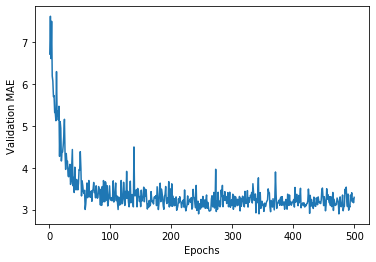

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

Exe. 9 (second serie)

In [ ]:
def smooth_curve(points, factor=0.9):
  smoothed_points = []
  for point in points:
    if smoothed_points:
      previous = smoothed_points[-1]
      smoothed_points.append(previous * factor + point * (1 - factor))
    else:
      smoothed_points.append(point)
  return smoothed_points


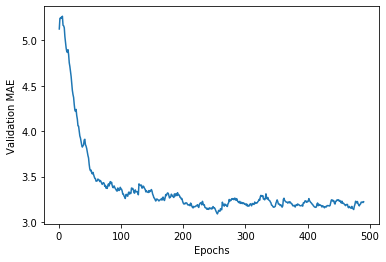

In [ ]:
smooth_mae_history = smooth_curve(average_mae_history[10:])
plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

Exe. 10 (second serie)

In [ ]:
model = build_model()
model.fit(train_data, train_targets, epochs=80, batch_size=16, verbose=0)
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

102/102 [==============================] - 0s 610us/sample - loss: 65.3724 - mae: 6.4365


Exe. 1

In [ ]:
from tensorflow import keras
keras.__version__

'2.2.4-tf'

In [ ]:
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)
print(train_data.shape, test_data.shape)

(25000,) (25000,)


In [ ]:
print((train_data[0]))
print(set(train_labels))

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
{0, 1}


Exe. 2

In [ ]:
def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s
    return results

In [ ]:
# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

Exe. 3

In [ ]:
import tensorflow as tf
from tensorflow import keras

original_model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(10000,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
original_model.compile(optimizer='rmsprop',
                       loss= 'binary_crossentropy',
                       metrics=['acc'])

Exe. 4

In [ ]:
smaller_model = keras.Sequential([
    keras.layers.Dense(4, activation='relu', input_shape=(10000,)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
smaller_model.compile(optimizer='rmsprop',
                       loss= 'binary_crossentropy',
                       metrics=['acc'])

Exe. 5

In [ ]:
original_hist = original_model.fit(x_train, y_train,
                                   epochs=20,
                                   batch_size=512,
                                   validation_data=(x_test, y_test))

Train on 25000 samples, validate on 25000 samples
Epoch 1/20
25000/25000 [==============================] - 4s 175us/sample - loss: 0.4498 - acc: 0.8321 - val_loss: 0.3390 - val_acc: 0.8814
Epoch 2/20
25000/25000 [==============================] - 3s 122us/sample - loss: 0.2636 - acc: 0.9100 - val_loss: 0.2982 - val_acc: 0.8811
Epoch 3/20
25000/25000 [==============================] - 3s 122us/sample - loss: 0.2021 - acc: 0.9277 - val_loss: 0.2818 - val_acc: 0.8876
Epoch 4/20
25000/25000 [==============================] - 3s 122us/sample - loss: 0.1681 - acc: 0.9394 - val_loss: 0.2906 - val_acc: 0.8852
Epoch 5/20
25000/25000 [==============================] - 3s 124us/sample - loss: 0.1460 - acc: 0.9488 - val_loss: 0.3078 - val_acc: 0.8800
Epoch 6/20
25000/25000 [==============================] - 3s 121us/sample - loss: 0.1273 - acc: 0.9566 - val_loss: 0.3526 - val_acc: 0.8689
Epoch 7/20
25000/25000 [==============================] - 3s 124us/sample - loss: 0.1110 - acc: 0.9621 - val_l

Exe. 6

In [ ]:
smaller_hist = smaller_model.fit(x_train, y_train,
                                       epochs=20,
                                       batch_size=512,
                                       validation_data=(x_test, y_test))

Train on 25000 samples, validate on 25000 samples
Epoch 1/20
25000/25000 [==============================] - 3s 133us/sample - loss: 0.5296 - acc: 0.8067 - val_loss: 0.4332 - val_acc: 0.8606
Epoch 2/20
25000/25000 [==============================] - 3s 115us/sample - loss: 0.3480 - acc: 0.8918 - val_loss: 0.3397 - val_acc: 0.8787
Epoch 3/20
25000/25000 [==============================] - 3s 116us/sample - loss: 0.2658 - acc: 0.9126 - val_loss: 0.2969 - val_acc: 0.8884
Epoch 4/20
25000/25000 [==============================] - 3s 113us/sample - loss: 0.2202 - acc: 0.9250 - val_loss: 0.2845 - val_acc: 0.8878
Epoch 5/20
25000/25000 [==============================] - 3s 115us/sample - loss: 0.1911 - acc: 0.9351 - val_loss: 0.2786 - val_acc: 0.8902
Epoch 6/20
25000/25000 [==============================] - 3s 114us/sample - loss: 0.1702 - acc: 0.9412 - val_loss: 0.2810 - val_acc: 0.8880
Epoch 7/20
25000/25000 [==============================] - 3s 116us/sample - loss: 0.1540 - acc: 0.9485 - val_l

Exe. 7

In [ ]:
epochs = range(1, 21)
original_val_loss = original_hist.history['val_loss']
smaller_model_val_loss = smaller_hist.history['val_loss']

Exe. 8

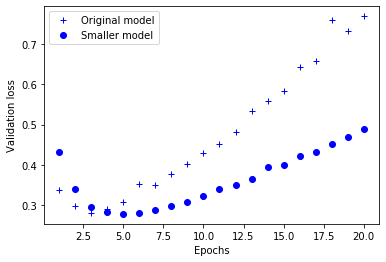

In [ ]:
import matplotlib.pyplot as plt

# b+ is for "blue cross"
plt.plot(epochs, original_val_loss, 'b+', label='Original model')
# "bo" is for "blue dot"
plt.plot(epochs, smaller_model_val_loss, 'bo', label='Smaller model')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()

plt.show()

Exe. 9

In [ ]:
bigger_model = keras.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(10000,)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
bigger_model.compile(optimizer='rmsprop',
                       loss= 'binary_crossentropy',
                       metrics=['acc'])

Exe. 10

In [ ]:
bigger_hist = bigger_model.fit(x_train, y_train,
                                     epochs=20,
                                     batch_size=512,
                                     validation_data=(x_test, y_test))

Train on 25000 samples, validate on 25000 samples
Epoch 1/20
25000/25000 [==============================] - 13s 505us/sample - loss: 0.1625 - acc: 0.9375 - val_loss: 0.3044 - val_acc: 0.8870
Epoch 2/20
25000/25000 [==============================] - 12s 495us/sample - loss: 0.0853 - acc: 0.9695 - val_loss: 1.5030 - val_acc: 0.6746
Epoch 3/20
25000/25000 [==============================] - 12s 500us/sample - loss: 0.0670 - acc: 0.9811 - val_loss: 0.3750 - val_acc: 0.8818
Epoch 4/20
25000/25000 [==============================] - 12s 499us/sample - loss: 0.0048 - acc: 0.9994 - val_loss: 0.6482 - val_acc: 0.8796
Epoch 5/20
25000/25000 [==============================] - 12s 497us/sample - loss: 0.1066 - acc: 0.9888 - val_loss: 0.5971 - val_acc: 0.8770
Epoch 6/20
25000/25000 [==============================] - 12s 497us/sample - loss: 5.1352e-04 - acc: 1.0000 - val_loss: 0.7977 - val_acc: 0.8770
Epoch 7/20
25000/25000 [==============================] - 13s 502us/sample - loss: 0.1015 - acc: 0.9

Exe. 11

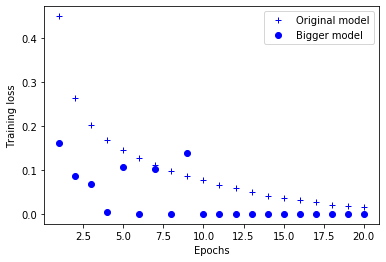

In [ ]:
original_train_loss = original_hist.history['loss']
bigger_model_train_loss = bigger_hist.history['loss']

plt.plot(epochs, original_train_loss, 'b+', label='Original model')
plt.plot(epochs, bigger_model_train_loss, 'bo', label='Bigger model')
plt.xlabel('Epochs')
plt.ylabel('Training loss')
plt.legend()

plt.show()

Exe. 12

In [ ]:
l2_model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(10000,), kernel_regularizer= keras.regularizers.l2(0.001)),
    keras.layers.Dense(16, activation='relu',  kernel_regularizer= keras.regularizers.l2(0.001)),
    keras.layers.Dense(1, activation='sigmoid')
])
l2_model.compile(optimizer='rmsprop',
                       loss= 'binary_crossentropy',
                       metrics=['acc'])

Exe. 13

In [ ]:
l2_model_hist = l2_model.fit(x_train, y_train,
                             epochs=20,
                             batch_size=512,
                             validation_data=(x_test, y_test))

Train on 25000 samples, validate on 25000 samples
Epoch 1/20
25000/25000 [==============================] - 5s 208us/sample - loss: 0.4929 - acc: 0.8152 - val_loss: 0.3797 - val_acc: 0.8807
Epoch 2/20
25000/25000 [==============================] - 3s 125us/sample - loss: 0.3121 - acc: 0.9058 - val_loss: 0.3385 - val_acc: 0.8837
Epoch 3/20
25000/25000 [==============================] - 3s 125us/sample - loss: 0.2698 - acc: 0.9212 - val_loss: 0.3300 - val_acc: 0.8887
Epoch 4/20
25000/25000 [==============================] - 3s 125us/sample - loss: 0.2492 - acc: 0.9280 - val_loss: 0.3437 - val_acc: 0.8830
Epoch 5/20
25000/25000 [==============================] - 3s 124us/sample - loss: 0.2363 - acc: 0.9332 - val_loss: 0.3480 - val_acc: 0.8818
Epoch 6/20
25000/25000 [==============================] - 3s 124us/sample - loss: 0.2292 - acc: 0.9356 - val_loss: 0.3715 - val_acc: 0.8744
Epoch 7/20
25000/25000 [==============================] - 3s 125us/sample - loss: 0.2205 - acc: 0.9414 - val_l

Exe. 14

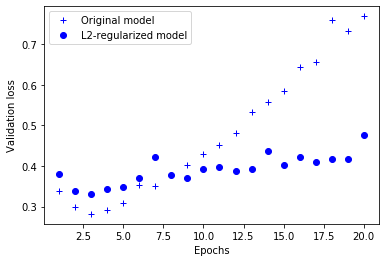

In [ ]:
l2_model_val_loss = l2_model_hist.history['val_loss']

plt.plot(epochs, original_val_loss, 'b+', label='Original model')
plt.plot(epochs, l2_model_val_loss, 'bo', label='L2-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()

plt.show()

Exe. 15

In [ ]:
dpt_model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(10000,)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

dpt_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])

Exe. 16

In [ ]:
dpt_hist = dpt_model.fit(x_train, y_train,
                               epochs=20,
                               batch_size=512,
                               validation_data=(x_test, y_test))

Train on 25000 samples, validate on 25000 samples
Epoch 1/20
25000/25000 [==============================] - 5s 211us/sample - loss: 0.5769 - acc: 0.6989 - val_loss: 0.4235 - val_acc: 0.8648
Epoch 2/20
25000/25000 [==============================] - 3s 122us/sample - loss: 0.4313 - acc: 0.8234 - val_loss: 0.3223 - val_acc: 0.8843
Epoch 3/20
25000/25000 [==============================] - 4s 178us/sample - loss: 0.3501 - acc: 0.8658 - val_loss: 0.2894 - val_acc: 0.8890
Epoch 4/20
25000/25000 [==============================] - 3s 137us/sample - loss: 0.2905 - acc: 0.8938 - val_loss: 0.2807 - val_acc: 0.8868
Epoch 5/20
25000/25000 [==============================] - 3s 121us/sample - loss: 0.2552 - acc: 0.9130 - val_loss: 0.2808 - val_acc: 0.8897
Epoch 6/20
25000/25000 [==============================] - 3s 121us/sample - loss: 0.2189 - acc: 0.9244 - val_loss: 0.2914 - val_acc: 0.8880
Epoch 7/20
25000/25000 [==============================] - 3s 122us/sample - loss: 0.1969 - acc: 0.9347 - val_l

Exe. 17

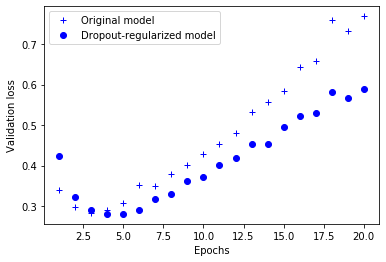

In [ ]:
dpt_model_val_loss = dpt_hist.history['val_loss']

plt.plot(epochs, original_val_loss, 'b+', label='Original model')
plt.plot(epochs, dpt_model_val_loss, 'bo', label='Dropout-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()

plt.show()